# 一文读懂隐马尔可夫模型（HMM）配套教学 Notebook

本 Notebook 配套文档「03_一文读懂隐马尔可夫模型（HMM）.md」，用同一套符号与同一组“天气—活动”示例参数，把 HMM 的三类核心问题（评估、解码、学习）跑通，并给出可复用的代码模板。


## 1. 学习目标

1. 理解离散观测 HMM 的五元组定义 $\lambda=(S, O, A, B, \pi)$。
2. 用前向算法计算观测序列似然 $P(\mathbf{O}\mid\lambda)$。
3. 用维特比算法求最可能的隐藏状态序列 $S^*$。
4. 了解参数学习的两种情形：状态可见的计数估计，以及状态不可见时的 Baum-Welch（EM）思路。


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows 标准 / Docker 挂载
        # Heiti TC: macOS 标准
        fonts = ["SimHei", "Heiti TC", "WenQuanYi Micro Hei", "DejaVu Sans"]
        rcParams["font.sans-serif"] = fonts
        rcParams["axes.unicode_minus"] = False
    except Exception:
        pass


config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 符号与参数：天气—活动示例

本节固定一套符号，后续所有推导与代码都以此为准：

- 隐藏状态集合：$S=\{\text{晴},\text{雨}\}$（按顺序编码为 0/1）
- 观测集合：$O=\{\text{散步},\text{购物},\text{打游戏}\}$（按顺序编码为 0/1/2）
- 初始分布：$\pi$，转移矩阵：$A$，发射矩阵：$B$

参数数值采用教学示例的经典设置（见配套文档参考文献中的 Wikipedia 条目与 Rabiner 教程综述）。


In [25]:
# ================== 参数设定（与文档一致） ==================
state_names = ["晴", "雨"]
obs_names = ["散步", "购物", "打游戏"]

# 初始分布 π
pi = np.array([0.6, 0.4], dtype=float)

# 状态转移矩阵 A（行：当前状态；列：下一状态）
A = np.array(
    [
        [0.7, 0.3],
        [0.4, 0.6],
    ],
    dtype=float,
)

# 发射矩阵 B（行：隐藏状态；列：观测符号）
B = np.array(
    [
        [0.6, 0.3, 0.1],
        [0.1, 0.4, 0.5],
    ],
    dtype=float,
)

# 观测序列 O = (散步, 购物, 打游戏)
obs_seq = np.array([0, 1, 2], dtype=int)

# ================== 合法性检查 ==================
assert np.isclose(pi.sum(), 1.0), "π 必须归一化"
assert np.allclose(A.sum(axis=1), 1.0), "A 的每一行之和必须为 1"
assert np.allclose(B.sum(axis=1), 1.0), "B 的每一行之和必须为 1"

pd.DataFrame(A, index=state_names, columns=state_names)

,晴,雨
晴,0.7,0.3
雨,0.4,0.6


In [26]:
pd.DataFrame(B, index=state_names, columns=obs_names)

,散步,购物,打游戏
晴,0.6,0.3,0.1
雨,0.1,0.4,0.5


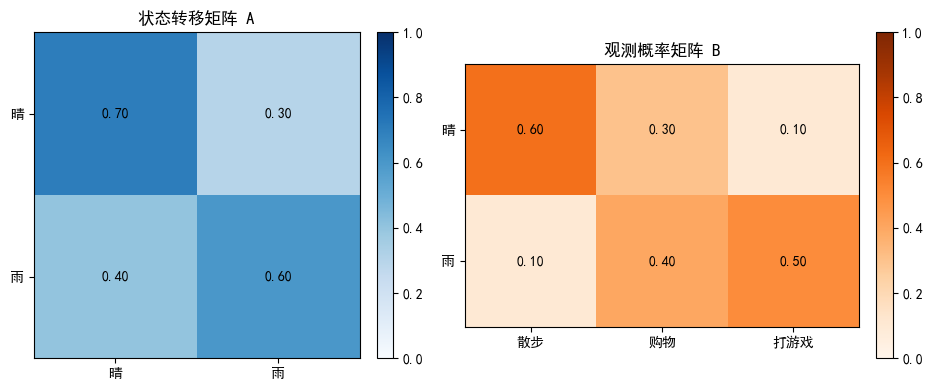

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(A, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("状态转移矩阵 A")
axes[0].set_xticks(range(len(state_names)))
axes[0].set_xticklabels(state_names)
axes[0].set_yticks(range(len(state_names)))
axes[0].set_yticklabels(state_names)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        axes[0].text(j, i, f"{A[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(B, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("观测概率矩阵 B")
axes[1].set_xticks(range(len(obs_names)))
axes[1].set_xticklabels(obs_names)
axes[1].set_yticks(range(len(state_names)))
axes[1].set_yticklabels(state_names)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        axes[1].text(j, i, f"{B[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 3. 评估问题：前向算法（Forward Algorithm）

评估问题的目标是计算 $P(\mathbf{O} \mid \lambda)$。前向算法使用动态规划，递推：

$$
\alpha_t(j)=\left[\sum_{i=1}^N \alpha_{t-1}(i)A_{ij}\right]B_j(o_t)
$$

最终 $P(\mathbf{O}\mid\lambda)=\sum_j \alpha_T(j)$。


In [28]:
def forward_algorithm(pi: np.ndarray, A: np.ndarray, B: np.ndarray, obs_seq: np.ndarray) -> tuple[np.ndarray, float]:
    """前向算法：返回 alpha 矩阵与观测序列概率。

    参数说明：
    - pi: 初始分布，形状 (N,)
    - A: 转移矩阵，形状 (N, N)
    - B: 发射矩阵，形状 (N, M)
    - obs_seq: 观测序列，形状 (T,)
    """
    n_states = A.shape[0]
    T = obs_seq.shape[0]
    alpha = np.zeros((T, n_states), dtype=float)

    # 初始化：alpha_1(j) = pi(j) * B_j(o_1)
    alpha[0] = pi * B[:, obs_seq[0]]

    # 递推：alpha_t(j) = [sum_i alpha_{t-1}(i) A_{ij}] * B_j(o_t)
    for t in range(1, T):
        alpha[t] = (alpha[t - 1] @ A) * B[:, obs_seq[t]]

    prob = float(alpha[-1].sum())
    return alpha, prob


alpha, p_obs = forward_algorithm(pi=pi, A=A, B=B, obs_seq=obs_seq)
alpha_df = pd.DataFrame(alpha, columns=state_names)
alpha_df.index = [f"t={t+1} ({obs_names[obs_seq[t]]})" for t in range(obs_seq.shape[0])]

alpha_df, p_obs

(                 晴       雨
 t=1 (散步)   0.36000  0.0400
 t=2 (购物)   0.08040  0.0528
 t=3 (打游戏)  0.00774  0.0279,
 0.035640000000000005)

In [29]:
# 与配套文档手算结果对齐：P(O|λ) = 0.03564
expected = 0.03564
assert abs(p_obs - expected) < 1e-10, f"结果不一致：{p_obs} vs {expected}"
print(f"P(O|λ) = {p_obs:.5f}（与文档一致）")

P(O|λ) = 0.03564（与文档一致）


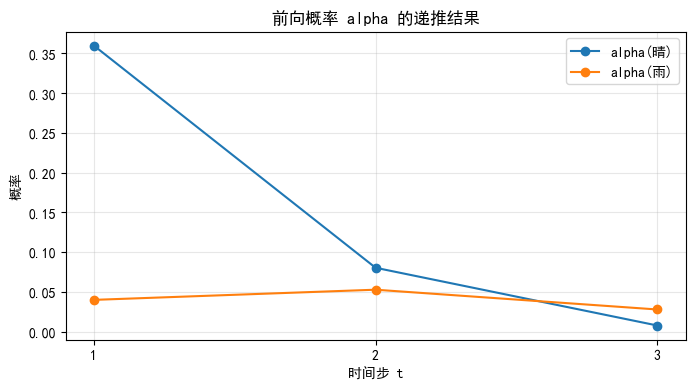

In [30]:
# 可视化 alpha 随时间变化
fig, ax = plt.subplots(figsize=(8, 4))
for s_idx, s_name in enumerate(state_names):
    ax.plot(alpha[:, s_idx], marker="o", label=f"alpha({s_name})")

ax.set_title("前向概率 alpha 的递推结果")
ax.set_xlabel("时间步 t")
ax.set_xticks(range(obs_seq.shape[0]))
ax.set_xticklabels(["1", "2", "3"])
ax.set_ylabel("概率")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 4. 解码问题：维特比算法（Viterbi Algorithm）

解码问题希望找到最可能的隐藏状态序列 $S^*$。维特比算法同样是动态规划，但将前向算法中的求和算子 $\sum$ 替换为最大化算子 $\max$，并记录回溯指针：

$$
\delta_t(j)=\max_i\left[\delta_{t-1}(i)A_{ij}\right]B_j(o_t),\quad
\psi_t(j)=\arg\max_i\left[\delta_{t-1}(i)A_{ij}\right]
$$


In [31]:
def viterbi_algorithm(pi: np.ndarray, A: np.ndarray, B: np.ndarray, obs_seq: np.ndarray) -> tuple[np.ndarray, np.ndarray, list[int], float]:
    """维特比算法：返回 delta、psi、最优路径与最优路径概率。"""
    n_states = A.shape[0]
    T = obs_seq.shape[0]

    delta = np.zeros((T, n_states), dtype=float)
    psi = np.zeros((T, n_states), dtype=int)

    # 初始化
    delta[0] = pi * B[:, obs_seq[0]]
    psi[0] = -1

    # 递推
    for t in range(1, T):
        for j in range(n_states):
            scores = delta[t - 1] * A[:, j]
            best_prev = int(np.argmax(scores))
            delta[t, j] = scores[best_prev] * B[j, obs_seq[t]]
            psi[t, j] = best_prev

    # 终止与回溯
    last_state = int(np.argmax(delta[-1]))
    best_prob = float(delta[-1, last_state])

    path = [last_state]
    for t in range(T - 1, 0, -1):
        path.append(int(psi[t, path[-1]]))
    path.reverse()

    return delta, psi, path, best_prob


delta, psi, best_path, best_prob = viterbi_algorithm(pi=pi, A=A, B=B, obs_seq=obs_seq)
decoded_states = [state_names[i] for i in best_path]

pd.DataFrame(delta, columns=state_names), decoded_states, best_prob

(          晴        雨
 0  0.360000  0.04000
 1  0.075600  0.04320
 2  0.005292  0.01296,
 ['晴', '雨', '雨'],
 0.012960000000000001)

In [32]:
# 与配套文档手算结果对齐：最优路径为 晴 → 雨 → 雨
assert decoded_states == ["晴", "雨", "雨"], f"最优路径不一致：{decoded_states}"
print(f"最优隐藏状态路径: {decoded_states}，路径概率: {best_prob:.5f}")

最优隐藏状态路径: ['晴', '雨', '雨']，路径概率: 0.01296


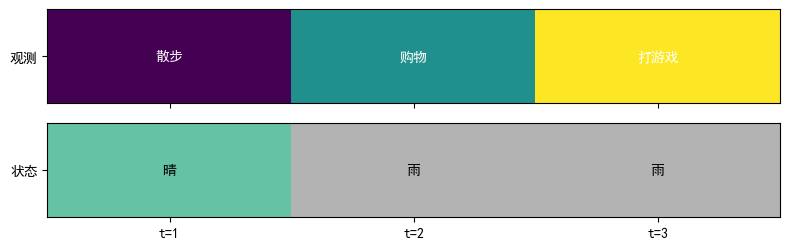

In [33]:
T = obs_seq.shape[0]
fig, axes = plt.subplots(2, 1, figsize=(8, 2.6), sharex=True)

axes[0].imshow(obs_seq.reshape(1, -1), aspect="auto", cmap="viridis", vmin=0, vmax=len(obs_names) - 1)
axes[0].set_yticks([0])
axes[0].set_yticklabels(["观测"])
for t in range(T):
    axes[0].text(t, 0, obs_names[int(obs_seq[t])], ha="center", va="center", color="white")

axes[1].imshow(np.array(best_path).reshape(1, -1), aspect="auto", cmap="Set2", vmin=0, vmax=len(state_names) - 1)
axes[1].set_yticks([0])
axes[1].set_yticklabels(["状态"])
for t in range(T):
    axes[1].text(t, 0, state_names[int(best_path[t])], ha="center", va="center", color="black")

axes[1].set_xticks(range(T))
axes[1].set_xticklabels([f"t={t+1}" for t in range(T)])
plt.tight_layout()
plt.show()


## 5. 学习问题：参数估计的两种情形

学习问题的目标是从数据估计模型参数 $\lambda=(A,B,\pi)$。实践中常见两种情形：

1. **状态可见（监督）**：可以直接对状态序列做计数，得到极大似然估计。
2. **状态不可见（无监督）**：需要用 Baum-Welch（EM）在“隐状态后验期望”与“参数更新”之间迭代。


### 5.1 状态可见时的计数估计（监督 MLE）

为了把学习问题的“更新逻辑”讲清楚，这里先用一个可控的监督版本演示：假设我们收集到了多条序列，每条序列都包含（隐藏状态序列，观测序列）。此时：

- $\hat{\pi}$ 等于起始状态的频率
- $\hat{A}_{ij}$ 等于从 $i\to j$ 的转移频率
- $\hat{B}_{j}(k)$ 等于在状态 $j$ 下观测到符号 $o_k$ 的频率


In [34]:
rng = np.random.default_rng(7)


def sample_hmm_sequence(pi: np.ndarray, A: np.ndarray, B: np.ndarray, T: int, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """从离散观测 HMM 采样 (states, observations)。"""
    n_states = A.shape[0]
    n_obs = B.shape[1]

    states = np.zeros(T, dtype=int)
    obs = np.zeros(T, dtype=int)

    states[0] = int(rng.choice(n_states, p=pi))
    obs[0] = int(rng.choice(n_obs, p=B[states[0]]))

    for t in range(1, T):
        states[t] = int(rng.choice(n_states, p=A[states[t - 1]]))
        obs[t] = int(rng.choice(n_obs, p=B[states[t]]))

    return states, obs


def fit_hmm_supervised(state_seqs: list[np.ndarray], obs_seqs: list[np.ndarray], n_states: int, n_obs: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """监督估计 (pi, A, B)：基于计数频率的 MLE。"""
    pi_counts = np.zeros(n_states, dtype=float)
    A_counts = np.zeros((n_states, n_states), dtype=float)
    B_counts = np.zeros((n_states, n_obs), dtype=float)

    for states, obs in zip(state_seqs, obs_seqs, strict=True):
        pi_counts[states[0]] += 1
        for t in range(states.shape[0] - 1):
            A_counts[states[t], states[t + 1]] += 1
        for s, o in zip(states, obs, strict=True):
            B_counts[s, o] += 1

    pi_hat = pi_counts / pi_counts.sum()
    A_hat = A_counts / A_counts.sum(axis=1, keepdims=True)
    B_hat = B_counts / B_counts.sum(axis=1, keepdims=True)
    return pi_hat, A_hat, B_hat


# 生成一批带隐状态标注的序列
n_sequences = 500
T = 30
state_seqs, obs_seqs = [], []
for _ in range(n_sequences):
    states, obs = sample_hmm_sequence(pi=pi, A=A, B=B, T=T, rng=rng)
    state_seqs.append(states)
    obs_seqs.append(obs)

pi_hat, A_hat, B_hat = fit_hmm_supervised(
    state_seqs=state_seqs,
    obs_seqs=obs_seqs,
    n_states=A.shape[0],
    n_obs=B.shape[1],
)

print("真实 π:", pi)
print("估计 π:", np.round(pi_hat, 3))
print("\n真实 A:\n", A)
print("估计 A:\n", np.round(A_hat, 3))
print("\n真实 B:\n", B)
print("估计 B:\n", np.round(B_hat, 3))

真实 π: [0.6 0.4]
估计 π: [0.596 0.404]

真实 A:
 [[0.7 0.3]
 [0.4 0.6]]
估计 A:
 [[0.704 0.296]
 [0.401 0.599]]

真实 B:
 [[0.6 0.3 0.1]
 [0.1 0.4 0.5]]
估计 B:
 [[0.584 0.314 0.103]
 [0.095 0.405 0.499]]


### 5.2 状态不可见时的 Baum-Welch（EM）演示（可选）

当隐藏状态不可观测时，无法直接计数得到 $A$ 与 $B$。Baum-Welch 将 HMM 的学习问题视为 EM 的特例：

- E 步：用前向-后向计算 $\gamma_t(i)$ 与 $\xi_t(i,j)$ 的期望
- M 步：用期望次数更新 $A$ 与 $B$

工程实践中常用 `hmmlearn` 进行演示与快速原型验证（参考文献：hmmlearn 官方文档）。如果环境里未安装 `hmmlearn`，该小节会自动跳过，并给出安装提示。


In [35]:
!pip install hmmlearn

In [36]:
try:
    from hmmlearn import hmm
except Exception as e:
    hmm = None
    print("未检测到 hmmlearn，跳过 Baum-Welch 演示。")
    print("安装方式示例：pip install hmmlearn")

if hmm is not None:
    # ================== 用 hmmlearn 做无监督学习演示 ==================
    # 注意：hmmlearn 期望二维输入 (n_samples, n_features)，离散观测通常用 (T, 1)
    X = np.concatenate([seq.reshape(-1, 1) for seq in obs_seqs], axis=0)
    lengths = [seq.shape[0] for seq in obs_seqs]

    if hasattr(hmm, "CategoricalHMM"):
        model = hmm.CategoricalHMM(n_components=2, n_iter=200, tol=1e-4, verbose=False, random_state=7, init_params="")
    else:
        model = hmm.MultinomialHMM(n_components=2, n_iter=200, tol=1e-4, verbose=False, random_state=7, init_params="")
        if hasattr(model, "n_trials"):
            model.n_trials = 1

    # 初始化（随机初始化更贴近“无先验”场景）
    model.startprob_ = rng.dirichlet(np.ones(2))
    model.transmat_ = rng.dirichlet(np.ones(2), size=2)
    model.emissionprob_ = rng.dirichlet(np.ones(3), size=2)

    model.fit(X, lengths)

    print("学习到的 startprob_:", np.round(model.startprob_, 3))
    print("学习到的 transmat_:\n", np.round(model.transmat_, 3))
    print("学习到的 emissionprob_:\n", np.round(model.emissionprob_, 3))

学习到的 startprob_: [0.079 0.921]
学习到的 transmat_:
 [[0.163 0.837]
 [0.443 0.557]]
学习到的 emissionprob_:
 [[0.396 0.303 0.301]
 [0.367 0.378 0.255]]


## 6. 小练习

1. 把 $\pi$ 改成 $[0.5,0.5]$，重新计算前向概率与维特比路径。
2. 保持每行和为 1，自定义一组 $A$ 或 $B$，观察 $P(\mathbf{O}\mid\lambda)$ 与最优路径的变化。
3. 增加序列长度（例如 50、100），对比前向算法在概率域与对数域实现的数值稳定性差异（提示：对数域计算可缓解下溢）。


## 7. 参考资料

1. Rabiner, L. R. (1989). *A tutorial on hidden Markov models and selected applications in speech recognition*. Proceedings of the IEEE, 77(2), 257-286.
2. hmmlearn documentation: https://hmmlearn.readthedocs.io/
3. Wikipedia contributors. Hidden Markov model: https://en.wikipedia.org/wiki/Hidden_Markov_model
